In [2]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dosyanın Kilidini Aç
dosya = uproot.open("/home/yusuf/geant4_work/TANK_SIMULATION/build/TankData.root")

dosya


<ReadOnlyDirectory '/' at 0x7ab417386000>


--- GERÇEK PARÇACIK VERİLERİ ---
   EventID  PMT_No    Time_ns
1        0       7   5.155641
2        0       6  19.724813
3        0       6  12.444461
4        0       4  73.546463
5        0       2  61.626579

Toplam yakalanan: 32670


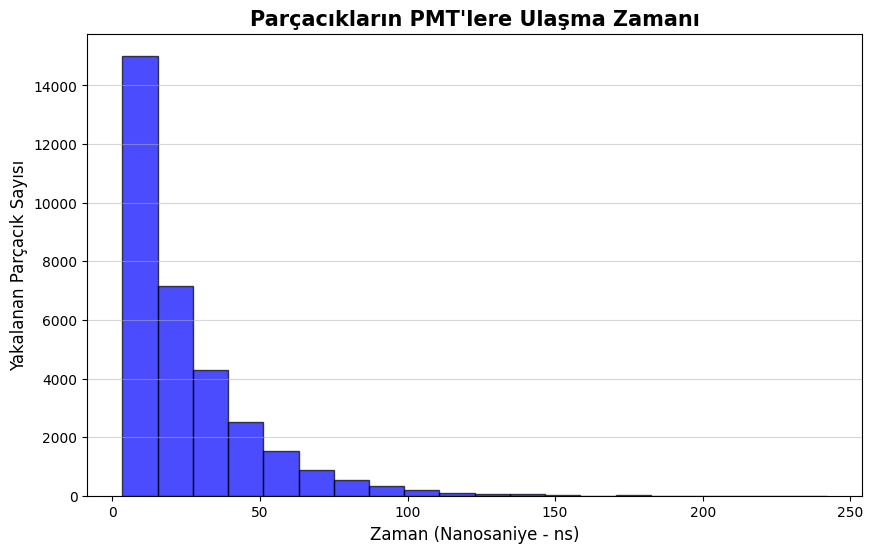

In [3]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dosyanın Kilidini Aç

tablo = dosya["PMT_Hits"]
df = tablo.arrays(library="pd")

# ======================================================
# SAHTE AJANI (999) SİLİP ATIYORUZ!
df = df[df["EventID"] != 999]
# ======================================================

print("\n--- GERÇEK PARÇACIK VERİLERİ ---")
print(df.head())
print(f"\nToplam yakalanan: {len(df)}")

# 4. Fiziği Görselleştir
plt.figure(figsize=(10, 6))

# Sadece gerçek zamanları çizdir (Artık 999 yok!)
plt.hist(df["Time_ns"], bins=20, color='blue', edgecolor='black', alpha=0.7)

plt.title("Parçacıkların PMT'lere Ulaşma Zamanı", fontsize=15, fontweight='bold')
plt.xlabel("Zaman (Nanosaniye - ns)", fontsize=12)
plt.ylabel("Yakalanan Parçacık Sayısı", fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()